In [1]:
from typing import Literal

import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
from scipy.linalg import cholesky
import seaborn as sns


/home/icb/lorenzo.consoli/miniconda3/envs/sc_exp_design/lib/python3.12/site-packages/scanpy/_utils/__init__.py:35: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/home/icb/lorenzo.consoli/miniconda3/envs/sc_exp_design/lib/python3.12/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/home/icb/lorenzo.consoli/miniconda3/envs/sc_exp_design/lib/python3.12/site-packages/scanpy/readwrite.py:15: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


In [2]:
adata_path = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/data/gdrive/new_dataset/BloodPlus_celltype_pm_500k_filtered_.h5ad"
adata = sc.read_h5ad(adata_path)
adata


AnnData object with n_obs × n_vars = 471836 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD', 'leiden', 'leiden_sub', 'leiden_old', 'cell_type'
    var: 'n', 'channel', 'marker', 'PnB', 'PnE', 'PnR', 'PnD', 'signal_type', 'antibody'
    uns: 'cell_type_colors', 'leiden', 'leiden_colors', 'leiden_colors_old',

In [3]:
scatter_columns = ['FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width']

In [4]:
X = np.concat(
    (adata.X, adata.obs[scatter_columns].values), axis=-1
)
X.shape

(471836, 26)

In [5]:
def get_data_params(X: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    # rowvar=False means columns are variables, rows are observations
    mean = np.mean(X, axis=0)
    cov = np.cov(X, rowvar=False) 
    return mean, cov

def compute_whitening_matrix(
    X: np.ndarray,
    epsilon: float = 1e-5,
    method: Literal["zca", "pca", "cholesky"] = "zca"
) -> np.ndarray:
    # get params
    mean, cov = get_data_params(X)

    # SVD is generally more numerically stable than np.linalg.eig
    U, S, VT = np.linalg.svd(cov)
    
    # Standard PCA whitening matrix: W_pca = S^{-1/2} * U^T
    # We use epsilon to avoid division by zero
    W_pca = np.dot(np.diag(1.0 / np.sqrt(S + epsilon)), U.T)

    if method == "pca":
        return W_pca, mean
    
    elif method == "zca":
        # ZCA is PCA rotated back: W_zca = U * W_pca
        return np.dot(U, W_pca), mean
    
    elif method == "cholesky":
        # Cholesky produces a lower triangular matrix L such that L*L.T = Cov
        # For whitening, we need the inverse of the factor
        L = cholesky(cov, lower=True)
        return np.linalg.inv(L), mean

    raise ValueError(f"Unknown method: {method}")

# Usage:
W_zca, m = compute_whitening_matrix(X, method="zca")
W_pca, m = compute_whitening_matrix(X, method="pca")
W_cholesky, m = compute_whitening_matrix(X, method="cholesky")

X_white_zca = (X - m) @ W_zca.T
X_white_pca = (X - m) @ W_pca.T
X_white_cholesky = (X - m) @ W_cholesky.T
X_zscore = (X - m)/np.std(X, axis=0)


<Axes: title={'center': 'Cholesky Whitening Matrix'}>

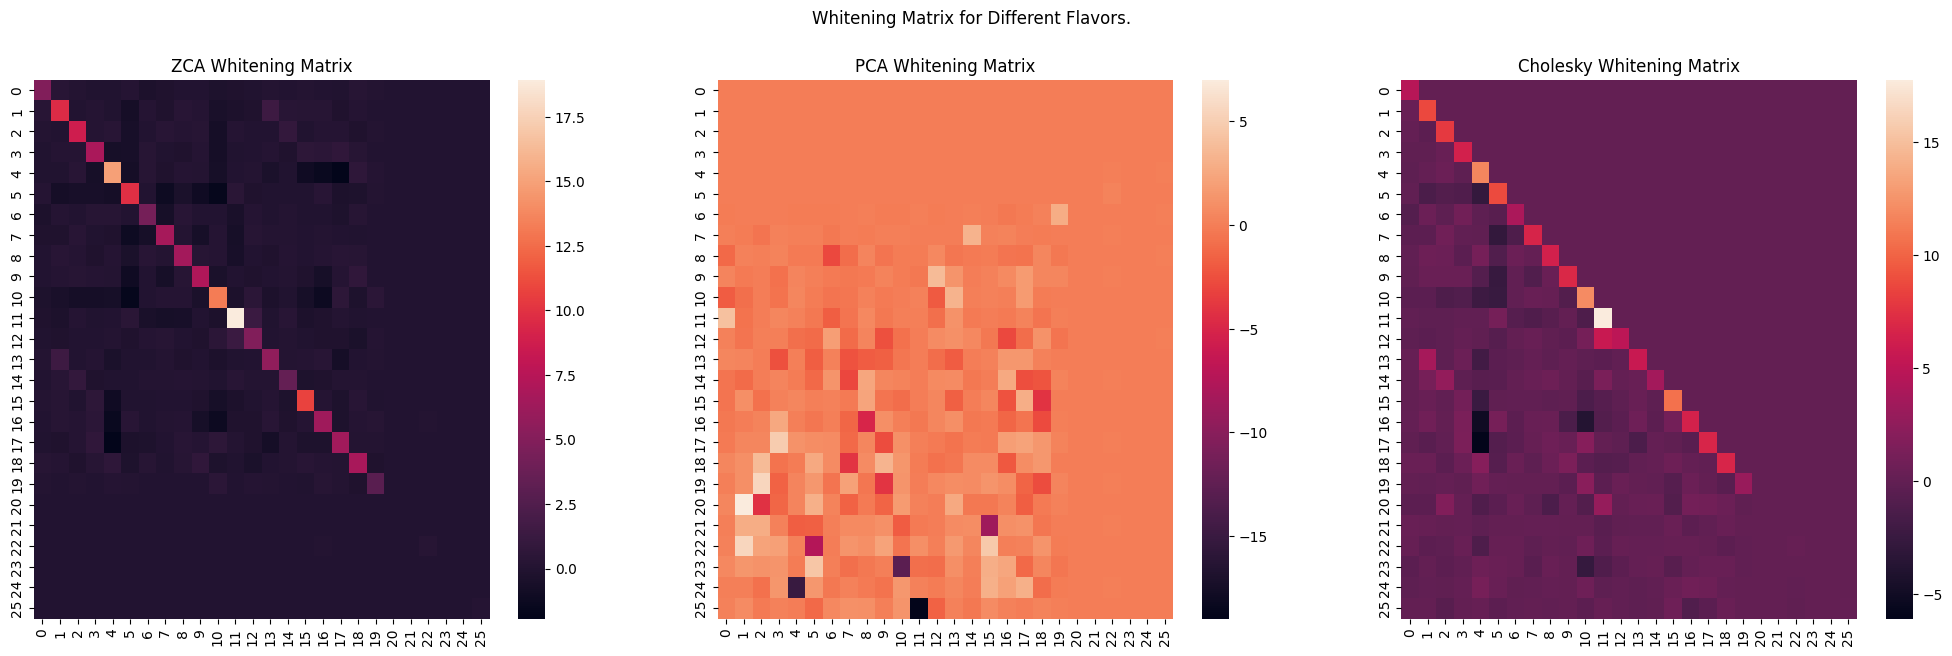

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(25, 7))
fig.suptitle("Whitening Matrix for Different Flavors.")
ax[0].set_title("ZCA Whitening Matrix")
sns.heatmap(W_zca, ax=ax[0])
ax[1].set_title("PCA Whitening Matrix")
sns.heatmap(W_pca, ax=ax[1])
ax[2].set_title("Cholesky Whitening Matrix")
sns.heatmap(W_cholesky, ax=ax[2])

<Axes: title={'center': 'Original Data'}>

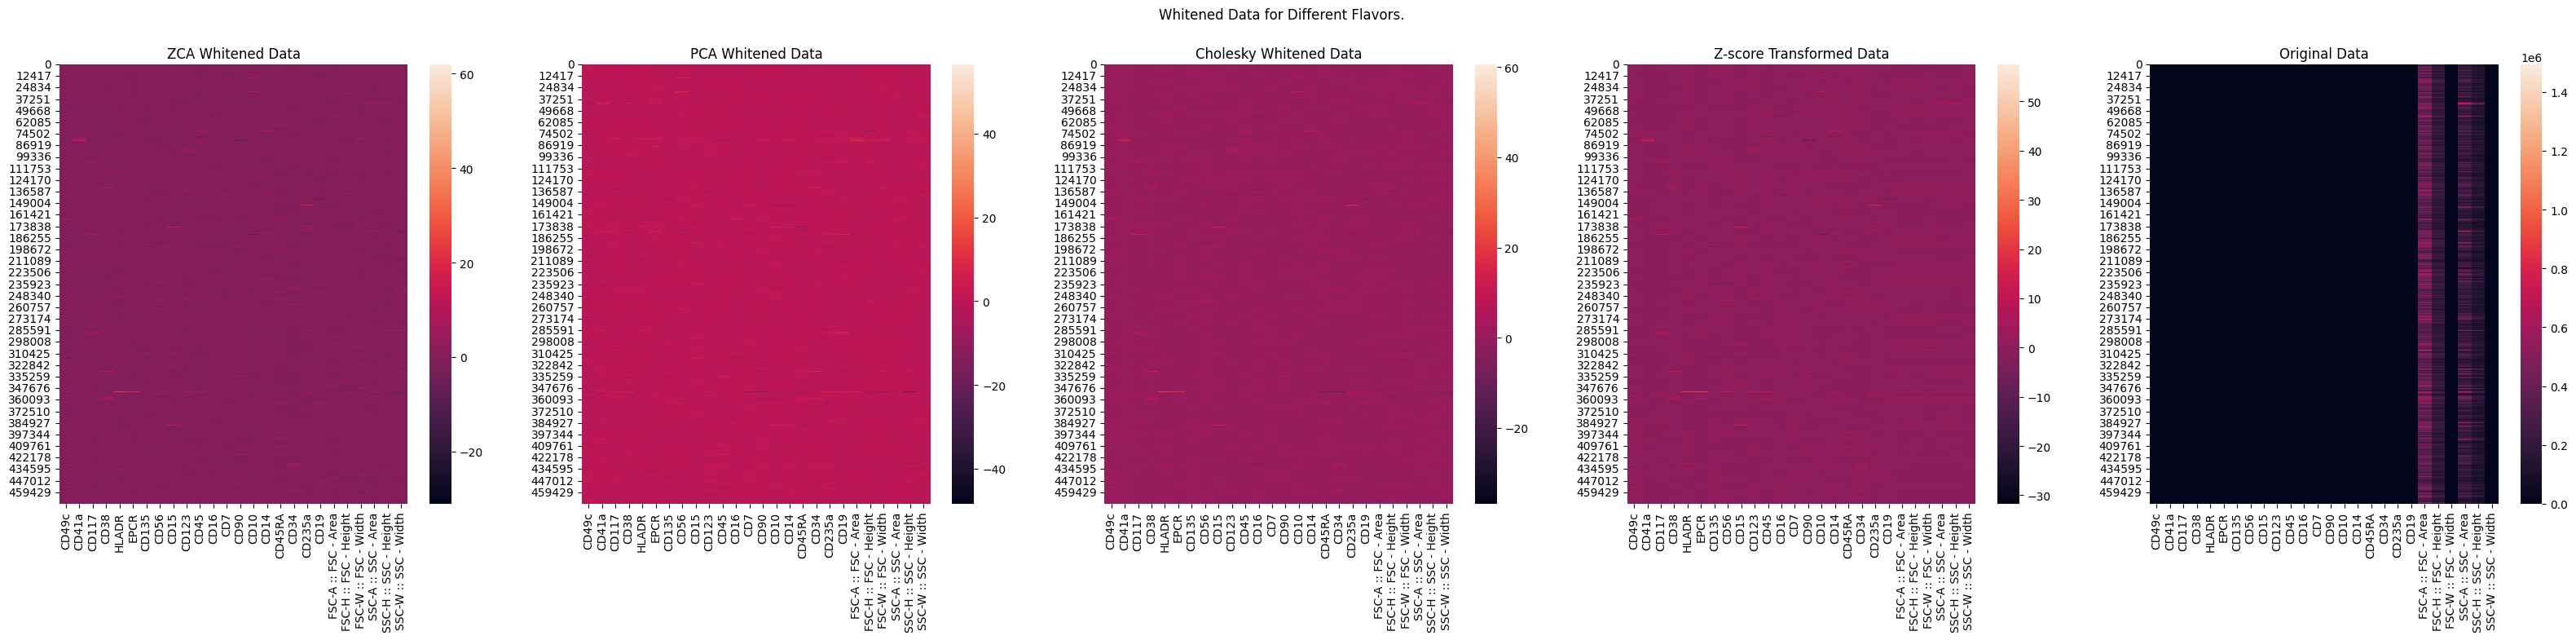

In [7]:
x_labels = adata.var_names.tolist() + scatter_columns
fig, ax = plt.subplots(1, 5, figsize=(40, 7))
fig.suptitle("Whitened Data for Different Flavors.")
ax[0].set_title("ZCA Whitened Data")
sns.heatmap(X_white_zca, ax=ax[0], xticklabels=x_labels)
ax[1].set_title("PCA Whitened Data")
sns.heatmap(X_white_pca, ax=ax[1], xticklabels=x_labels)
ax[2].set_title("Cholesky Whitened Data")
sns.heatmap(X_white_cholesky, ax=ax[2], xticklabels=x_labels)
ax[3].set_title("Z-score Transformed Data")
sns.heatmap(X_zscore, ax=ax[3], xticklabels=x_labels)
ax[4].set_title("Original Data")
sns.heatmap(X, ax=ax[4], xticklabels=x_labels)